<a href="https://colab.research.google.com/github/iav2002/Assignment_Advanced_Topics_In_DeepLearning/blob/main/part2_EmbeddingsAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part 2 — Embeddings extraction and t-SNE visualization

This notebook closes Part 2 by producing the artifacts that Part 3 needs.

 We load the best model from the experiments (Variant C from Exp 1, progressive unfreezing on ResNet50 at 99.05% test accuracy), run the test images of the four required classes through the backbone to extract feature embeddings, and save the per class mean embedding so the DQN agent in Part 3 can use them as state inputs without recomputing forward passes.

We also produce a t-SNE plot of the individual embeddings to give visual evidence that the model has learned to separate the four classes cleanly, which is what makes the mean embedding meaningful as a class representative.

## 1. Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import json, time
from pathlib import Path
from collections import defaultdict

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'device: {device}')

Mounted at /content/drive
device: cuda


## 2. Paths and config

Same paths as Exp 1. We load the test set sample index and the Variant C checkpoint. The four classes we care about for Part 3 are floor, wall, pallet and sign.

In [2]:
DRIVE_ROOT = Path('/content/drive/MyDrive/Colab Notebooks/AdvancedDL')
INDEX_DIR = DRIVE_ROOT / 'sample_index'
LOCAL_ROOT = Path('/content/dataset_local')
DRIVE_RAW = DRIVE_ROOT / 'raw'

# variant C of exp1 was the top performer
CKPT_PATH = DRIVE_ROOT / 'results' / 'exp1_gradual_unfreezing' / 'exp1_C' / 'best.pt'

# where part 3 will read embeddings from
EMB_DIR = DRIVE_ROOT / 'embeddings'
EMB_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE = 224
BATCH_SIZE = 128
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# the four classes part 3 needs
TARGET_CLASSES = ['floor', 'wall', 'pallet', 'sign']

print(f'checkpoint: {CKPT_PATH}')
print(f'embeddings out: {EMB_DIR}')

checkpoint: /content/drive/MyDrive/Colab Notebooks/AdvancedDL/results/exp1_gradual_unfreezing/exp1_C/best.pt
embeddings out: /content/drive/MyDrive/Colab Notebooks/AdvancedDL/embeddings


## 3. Load test sample index and filter to the 4 classes

Reads the test JSON from EDA, keeps only floor, wall, pallet and sign, rewrites paths to local SSD.

In [3]:
with open(INDEX_DIR / 'samples_test.json') as f:
    samples_test = json.load(f)
with open(INDEX_DIR / 'class_vocab.json') as f:
    vocab = json.load(f)

CLASS_TO_IDX = vocab['class_to_idx']
IDX_TO_CLASS = {int(k): v for k, v in vocab['idx_to_class'].items()}
NUM_CLASSES = len(CLASS_TO_IDX)

# rewrite paths drive to local
for s in samples_test:
    s['img_path'] = s['img_path'].replace(str(DRIVE_RAW), str(LOCAL_ROOT))

# keep only the four classes part 3 needs
target_ids = {CLASS_TO_IDX[c] for c in TARGET_CLASSES}
samples_filtered = [s for s in samples_test if s['label'] in target_ids]

print(f'total test samples: {len(samples_test):,}')
print(f'filtered to 4 classes: {len(samples_filtered):,}')
for c in TARGET_CLASSES:
    n = sum(1 for s in samples_filtered if s['class_name'] == c)
    print(f'  {c}: {n}')

total test samples: 2,750
filtered to 4 classes: 1,000
  floor: 250
  wall: 250
  pallet: 250
  sign: 250


In [6]:
import shutil
# 4min L4
EXPECTED = {'train': 4654, 'val': 1125, 'test': 1124}

def copy_split(split):
    src = DRIVE_RAW / split / 'images'
    dst = LOCAL_ROOT / split / 'images'
    dst.mkdir(parents=True, exist_ok=True)
    if len(list(dst.glob('*.png'))) == EXPECTED[split]:
        print(f'  {split}: already complete')
        return
    print(f'  {split}: copying {EXPECTED[split]} images...')
    t0 = time.time()
    shutil.copytree(src, dst, dirs_exist_ok=True)
    print(f'  {split}: copied in {time.time()-t0:.0f}s')

# only test split needed for embeddings, but copy all for consistency
print('copying test split to local SSD...')
copy_split('test')
print('done.')

copying test split to local SSD...
  test: copying 1124 images...
  test: copied in 189s
done.


## 4. Pre-load to RAM

Same in memory dataset as the experiments. Hits the cache if it survived from earlier runs.

In [7]:
def preload_to_ram(samples):
    n = len(samples)
    imgs = torch.empty((n, 3, IMG_SIZE, IMG_SIZE), dtype=torch.uint8)
    labels = torch.empty((n,), dtype=torch.long)
    t0 = time.time()
    for i, s in enumerate(samples):
        img = Image.open(s['img_path']).convert('RGB')
        x1, y1, x2, y2 = s['bbox']
        crop = img.crop((x1, y1, x2, y2)).resize((IMG_SIZE, IMG_SIZE))
        imgs[i] = torch.from_numpy(np.asarray(crop)).permute(2, 0, 1)
        labels[i] = s['label']
    print(f'loaded {n:,} crops in {time.time()-t0:.0f}s')
    return imgs, labels

class InMemoryDataset(Dataset):
    def __init__(self, imgs, labels):
        self.imgs = imgs; self.labels = labels
        self.mean = torch.tensor(IMAGENET_MEAN).view(3,1,1) * 255
        self.std = torch.tensor(IMAGENET_STD).view(3,1,1) * 255
    def __len__(self): return len(self.imgs)
    def __getitem__(self, i):
        x = self.imgs[i].float()
        return (x - self.mean) / self.std, self.labels[i]

imgs, labels = preload_to_ram(samples_filtered)
loader = DataLoader(InMemoryDataset(imgs, labels), batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
print(f'loader: {len(loader)} batches')

/tmp/ipykernel_31392/257728832.py:10: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  imgs[i] = torch.from_numpy(np.asarray(crop)).permute(2, 0, 1)


loaded 1,000 crops in 13s
loader: 8 batches


## 5. Load best model (Variant C from Exp 1)

Build a fresh ResNet50 with the same head shape (11 classes), then load the saved state dict from Variant C. The model was saved with all weights trainable (progressive unfreezing eventually unfroze the whole backbone), so loading is straightforward.

In [8]:
import torchvision.models as models

def build_model(num_classes):
    m = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
    m.fc = nn.Linear(m.fc.in_features, num_classes)
    return m

model = build_model(NUM_CLASSES).to(device)
ckpt = torch.load(CKPT_PATH, map_location=device)
model.load_state_dict(ckpt['model_state'])
model.eval()

print(f'loaded checkpoint from epoch {ckpt["epoch"]}')
print(f'val loss at save: {ckpt["val_loss"]:.4f}')
print(f'val acc at save:  {ckpt["val_acc"]:.4f}')

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 244MB/s]


loaded checkpoint from epoch 8
val loss at save: 0.0344
val acc at save:  0.9913


## 6. Extract embeddings via forward hook

The embedding is the 2048 dimensional vector that comes out of the last avgpool, just before the classification head. We attach a forward hook to `model.avgpool` to capture that tensor for every batch and stash it in a list.

In [9]:
# hook captures the avgpool output, shape [batch, 2048, 1, 1]
captured = []
def hook(module, inputs, output):
    captured.append(output.detach().squeeze(-1).squeeze(-1).cpu())

handle = model.avgpool.register_forward_hook(hook)

all_embeddings = []
all_labels = []
with torch.no_grad():
    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True)
        _ = model(xb)
        all_labels.append(yb)

handle.remove()

# stitch batches together into single tensors
embeddings = torch.cat(captured, dim=0).numpy()
all_labels = torch.cat(all_labels, dim=0).numpy()

print(f'embeddings shape: {embeddings.shape}')
print(f'labels shape:     {all_labels.shape}')

embeddings shape: (1000, 2048)
labels shape:     (1000,)


## 7. Compute and save mean embeddings per class

For each of the four classes, average the embeddings of all its test samples. Save as a single dict `.npy` so Part 3 can load it with one call.

In [10]:
mean_embeddings = {}
for c in TARGET_CLASSES:
    cls_idx = CLASS_TO_IDX[c]
    mask = all_labels == cls_idx
    cls_emb = embeddings[mask]
    mean_embeddings[c] = cls_emb.mean(axis=0)
    print(f'{c:8s}: {mask.sum()} samples, mean shape {mean_embeddings[c].shape}, '
          f'norm {np.linalg.norm(mean_embeddings[c]):.2f}')

# save as a dict so part 3 just does np.load(...).item()
np.save(EMB_DIR / 'mean_embeddings.npy', mean_embeddings, allow_pickle=True)
print(f'\nsaved to {EMB_DIR / "mean_embeddings.npy"}')

floor   : 250 samples, mean shape (2048,), norm 12.84
wall    : 250 samples, mean shape (2048,), norm 10.27
pallet  : 250 samples, mean shape (2048,), norm 12.65
sign    : 250 samples, mean shape (2048,), norm 14.09

saved to /content/drive/MyDrive/Colab Notebooks/AdvancedDL/embeddings/mean_embeddings.npy


## 8. t-SNE visualization

t-SNE projects the 2048 dimensional embeddings down to 2D for visualization. If the model has learned to separate the four classes, we expect to see four distinct clusters. Tightly packed clusters mean the mean embedding is a good representative; overlapping clusters would mean the per class mean is closer to a fuzzy average than a meaningful prototype.

`perplexity=30` is the default and works well for our sample sizes. `random_state` set for reproducibility.

running t-SNE...
done in 2s


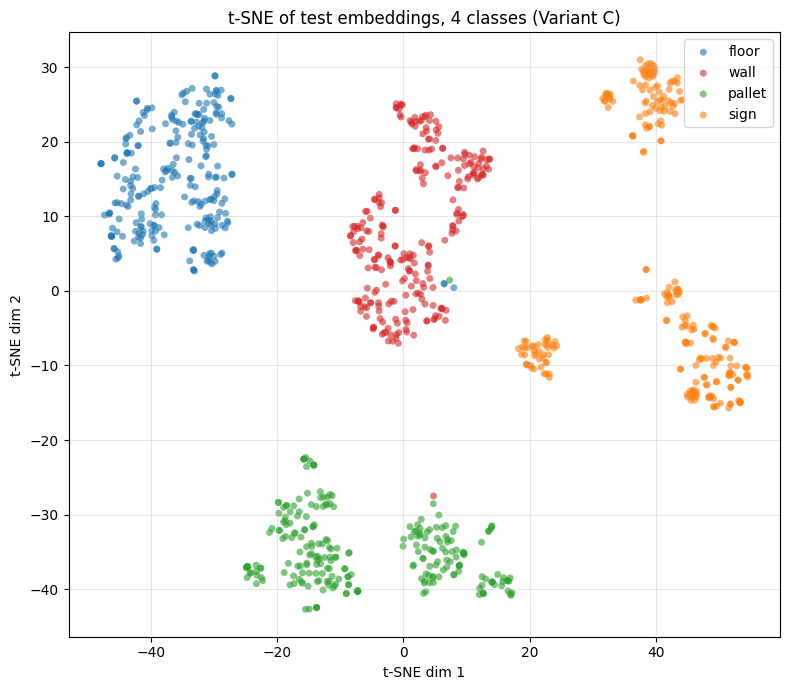

In [11]:
# 1-2 min on cpu
print('running t-SNE...')
t0 = time.time()
tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', learning_rate='auto')
emb_2d = tsne.fit_transform(embeddings)
print(f'done in {time.time()-t0:.0f}s')

fig, ax = plt.subplots(figsize=(8, 7))
colors = {'floor': '#1f77b4', 'wall': '#d62728', 'pallet': '#2ca02c', 'sign': '#ff7f0e'}

for c in TARGET_CLASSES:
    cls_idx = CLASS_TO_IDX[c]
    mask = all_labels == cls_idx
    ax.scatter(emb_2d[mask, 0], emb_2d[mask, 1],
               c=colors[c], label=c, alpha=0.6, s=25, edgecolors='none')

ax.set_xlabel('t-SNE dim 1')
ax.set_ylabel('t-SNE dim 2')
ax.set_title('t-SNE of test embeddings, 4 classes (Variant C)')
ax.legend(loc='best', frameon=True)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(EMB_DIR / 'tsne_4classes.png', dpi=120)
plt.show()